# Exact WKB

### what a divergent series is trying to tell you

The claim this notebook is about, stated up front.

> The WKB series of quantum mechanics diverges, for every potential and at every energy. That
> divergence is not a defect to be truncated away. Its *rate* is set by tunnelling, precisely the
> physics that no order of the series can see. In the complex plane the whole structure becomes
> visible as a **graph** you can draw.

We build that graph for three potentials and then check the claim numerically, computing a
tunnelling action two different ways: once as a contour integral, once by watching a perturbative
series diverge. The two agree to four digits.

Prerequisites are a first course in quantum mechanics and comfort with complex analysis. Everything
is computed live with [`ExactWKB.jl`](https://github.com/benedikt-nagler/ExactWKB.jl) and
[`Resurgence.jl`](https://github.com/benedikt-nagler/Resurgence.jl); nothing is quoted from a
paper.

## Where this comes from

Recall the standard WKB approximation. For

$$\hbar^2 \psi'' = Q(z)\,\psi, \qquad Q = V - E,$$

one writes

$$\psi(z) \;\approx\; \frac{1}{Q(z)^{1/4}} \exp\!\left(\pm\frac{1}{\hbar}\int^z \sqrt{Q(w)}\,dw\right).$$

Where $E > V$ the square root is imaginary and this oscillates: the classically allowed region.
Where $E < V$ it is real and the solution grows or decays exponentially, under the barrier. The
decaying branch is the tunnelling amplitude $e^{-S/\hbar}$, and counting oscillations gives the
Bohr–Sommerfeld quantisation condition.

Every course then runs into the same three problems.

**1. It fails exactly where you need it.** At a *turning point*, where $E = V(z)$, we have $Q = 0$
and the prefactor $Q^{-1/4}$ blows up. Turning points are the boundary between the allowed and
forbidden regions, so they are unavoidable. The standard patch is to zoom in, approximate $Q$ as
linear, solve exactly with Airy functions, and match asymptotics on either side. This works, but
the connection formulas arrive as a special-case computation, redone by hand for each new
configuration.

**2. The corrections diverge.** The formula above is only the leading term of a series in $\hbar$.
Compute more terms and the coefficients eventually grow like $n!$, so the series has zero radius of
convergence. It is asymptotic: good if you truncate near its smallest term, meaningless if you keep
going.

**3. It cannot see tunnelling at all.** Take a symmetric double well. Perturbing around one minimum
gives the energy levels as a power series in $\hbar$, and by symmetry the same series comes out of
the other minimum, so at every order the two levels are exactly degenerate. In reality tunnelling
splits them, by an amount

$$\Delta E \sim e^{-S_{\text{inst}}/\hbar}.$$

A function like $e^{-1/\hbar}$ has *every* Taylor coefficient at $\hbar = 0$ equal to zero, so the
splitting is invisible to the perturbative series to all orders.

### The resurgent idea

Problems 2 and 3 look like separate complaints. They are the same complaint.

Resurgence claims that a divergent series remembers what it cannot represent. If the coefficients
behave as

$$a_n \;\sim\; \frac{n!}{A^{\,n}},$$

then the constant $A$ controlling the growth *is* the action of the non-perturbative effect the
series is missing. Divergence is the series reporting, in the only language available to it, the
physics it was not built to express.

Exact WKB is where both sides of that statement can be computed and compared. What makes it
possible is to stop restricting $z$ to the real line. Once $z$ is complex, the turning points
become branch points of $\sqrt{Q}$, the connection problem becomes a question about analytic
continuation, and the bookkeeping organises itself into a graph.

| | potential | what it shows |
|---|---|---|
| §1 | $Q = z$ | the minimal graph: one turning point, three lines |
| §2 | $Q = z^3 - z$ | the graph jumps, which is the Stokes phenomenon |
| §3 | $Q = (z^2-1)^2 - \tfrac14$ | tunnelling, read off the divergence |

In [1]:
using Pkg; Pkg.activate(joinpath(@__DIR__, "..", "test"))
using ExactWKB
import Resurgence
using CairoMakie
CairoMakie.activate!(type = "png")

# turning points and periods are computed in BigFloat; round for display,
# chopping components that are zero to working precision
function r(x; n = 5)
    z = Complex{Float64}(x)
    a, b = real(z), imag(z)
    tol = 1e-12 * max(abs(a), abs(b), 1.0)
    abs(b) < tol && return round(a; sigdigits = n)
    abs(a) < tol && return round(b; sigdigits = n) * 1im
    round(z; sigdigits = n)
end
r(v::AbstractVector; n = 5) = r.(v; n)

showsaddle(s) = println("  turning points ", s.pair,
                       "   |Z| = ", round(Float64(mass(s)); digits = 5),
                       "   θ_c = ", round(Float64(s.theta); digits = 5))

showsaddle (generic function with 1 method)

## §1: the minimal graph

Start with the simplest potential that has a turning point at all: $V(z) = z$ at $E = 0$, so
$Q(z) = z$. This is the linear potential whose exact solution is the Airy function, the local model
every connection formula is built from.

A `SchrodingerProblem` takes the coefficients of $V$, lowest degree first.

In [2]:
airy = SchrodingerProblem([0, 1])   # V(z) = z,  E = 0  ⟹  Q(z) = z
println(airy)
println("Q(2) = ", airy(2.0))
turning_points(airy)

SchrodingerProblem(Q deg 1, E = 0.0)
Q(2) = 2.0


1-element Vector{TurningPoint{BigFloat}}:
 TurningPoint(-0.0 + 0.0im, simple)

One turning point, at the origin, as expected.

Now the key construction. Away from the turning point the two WKB solutions
$\psi_\pm \sim \exp(\pm\hbar^{-1}\!\int\!\sqrt{Q})$ differ by an exponential factor, so generically
one of them is much larger than the other: one is **dominant**, one **recessive**. Which is which
depends on where you stand in the complex plane.

The dividing curves are where neither wins, that is, where the exponent is purely oscillatory
rather than growing. Fixing a phase $\theta$ (think of it as the phase of $\hbar$), these are the
curves where

$$\mathrm{Im}\!\left[e^{-i\theta}\!\int_{z_*}^{z} \sqrt{Q(w)}\,dw\right] = 0,$$

emanating from a turning point $z_*$. They are called **Stokes lines**, and they matter for a
practical reason: on one, the recessive solution is maximally suppressed and therefore invisible.
You can add any multiple of it without changing what you measure. Cross the line and the roles of
dominant and recessive swap, so that invisible admixture becomes visible and the coefficient of the
recessive solution appears to jump discontinuously, even though the true solution is analytic.

That apparent jump is the **Stokes phenomenon**. The Stokes lines map where the bookkeeping has to
change, which makes them the connection problem from §*Where this comes from*, drawn as a picture
instead of solved case by case.

Near a simple turning point $\sqrt{Q} \sim \sqrt{z}$, so the integral goes like $z^{3/2}$ and exactly
**three** Stokes lines leave, at $120°$ to each other. This is the three-fold structure of the Airy
function's asymptotics, in graph form.

In [3]:
g_airy = stokes_graph(airy; theta = 0.0)
println(g_airy)
println("infinite lines : ", n_infinite_lines(g_airy))
println("finite edges   : ", edges(g_airy))

StokesGraph(θ = 0.0

, 1 TPs, 0 saddles, 3 rays→∞)
infinite lines : 3
finite edges   : 

Tuple{Int64, Int64}[]


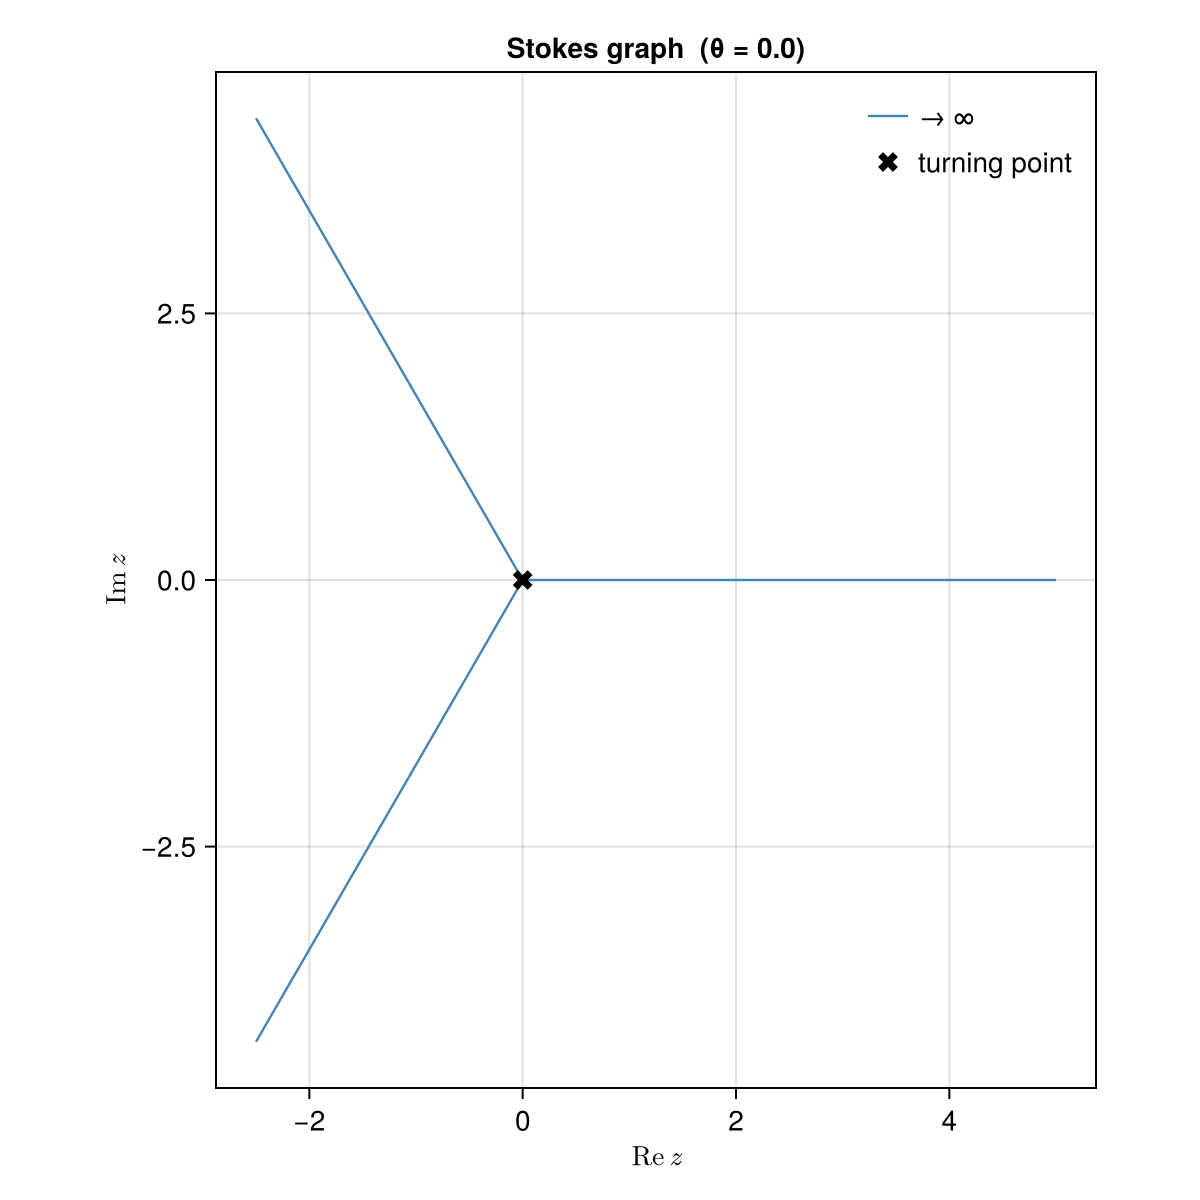

In [4]:
plot_stokes_graph(g_airy)

Three rays running off to infinity, and no *finite* edges: no Stokes line starts at one turning
point and ends at another.

This graph is **generic**. Perturb the potential or the phase and it wobbles, but nothing about it
changes qualitatively. That stability is what makes the next example interesting.

## §2: the graph jumps

Take a cubic, $Q = z^3 - z$, with three simple turning points at $z = -1, 0, +1$.

In [5]:
cubic = SchrodingerProblem([0.0, -1.0, 0.0, 1.0])   # Q = z³ − z
for t in turning_points(cubic)
    println("  z = ", r(location(t)), "   order ", order(t))
end

  z = -1.0   order 1
  z = 0.0   order 1
  z = 1.0   order 1


Three lines leave each turning point, so nine in total, and generically all nine escape to
infinity. At special phases something non-generic happens: a line leaving one turning point can
*land on another one*.

Such a finite Stokes line is called a **saddle connection**, and it is the geometric signature of a
non-perturbative object. It means there is a path along which the tunnelling exponent is real, that
is, a genuine tunnelling process connecting the two turning points.

Watch the line count as we rotate $\theta$.

In [6]:
for θ in (0.0, 0.1, 0.3, 0.6)
    g = stokes_graph(cubic; theta = θ)
    println("θ = ", rpad(θ, 4),
            "   infinite lines: ", n_infinite_lines(g),
            "   finite edges: ", edges(g))
end

θ = 0.0 

   infinite lines: 7   finite edges: [(1, 2)]
θ = 0.1    infinite lines: 9   finite edges: Tuple{Int64, Int64}[]
θ = 0.3    infinite lines: 9   finite edges: Tuple{Int64, Int64}[]
θ = 0.6    infinite lines: 9   finite edges: Tuple{Int64, Int64}[]


At $\theta = 0$: **seven** infinite lines, plus one finite edge joining turning points 1 and 2.
Rotate by a tenth of a radian and the connection snaps, the edge is gone, and the count jumps back
to **nine**. (Seven becomes nine because the two lines that had been terminating on turning point 2
are now free to escape.)

A discrete, discontinuous change in the topology of a graph, triggered by a continuous rotation of
a phase: that is the Stokes phenomenon of §1, no longer as a statement about invisible
exponentials, but as something you can see.

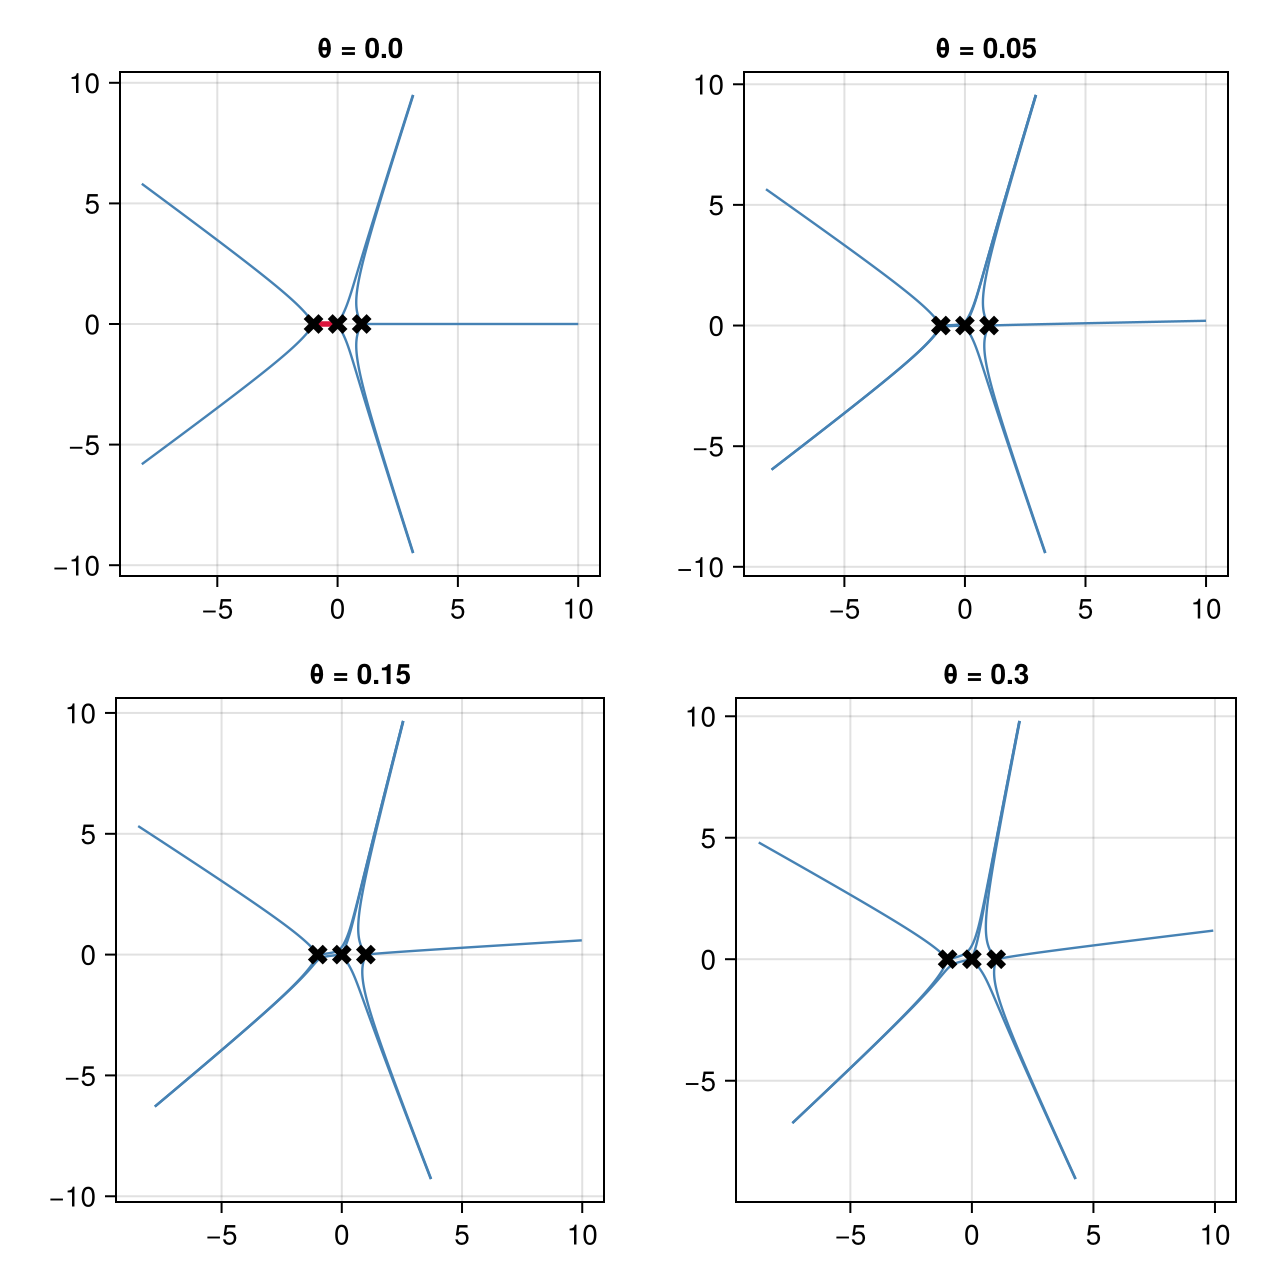

In [7]:
thetas = [0.0, 0.05, 0.15, 0.3]
plot_stokes_graph(stokes_graph_family(cubic, thetas))

The red edge in the first panel is the saddle connection; by the last it has vanished.

Each saddle connection carries a **central charge** $Z$, the period of $\sqrt{Q}$ along it. Its
modulus $|Z|$ is the action of the corresponding tunnelling process, the $S$ in $e^{-S/\hbar}$, and
its phase is the $\theta$ at which the connection forms. (In the physics literature these are BPS
states and $|Z|$ is their mass; the arithmetic is the same either way.)

In [8]:
foreach(showsaddle, saddles(cubic))

  turning points (

1, 2)   |Z| = 0.95851   θ_c = 0.0
  turning points (2, 3)   |Z| = 0.95851   θ_c = 1.5708


Two of them, degenerate at $|Z| \approx 0.9585$, forming at $\theta_c = 0$ and $\theta_c = \pi/2$.
The degeneracy is forced by the symmetry $Q(-z) = -Q(z)$.

So the Stokes graph is a **catalogue of non-perturbative effects**: rotate $\theta$ through a full
turn, record every phase at which a finite edge appears, and you have enumerated the tunnelling
processes available to the system, with their actions.

That is a strong claim. §3 tests it.

## §3: tunnelling, read off the divergence

Now the case the whole story was built for, the symmetric double well

$$V(z) = z^4 - 2z^2 + \tfrac34, \qquad E = 0,$$

so that $Q = V - E = (z^2-1)^2 - \tfrac14$. Two degenerate minima at $z = \pm 1$, separated by a
barrier: the standard setting for instanton physics.

Before any complex analysis, the familiar real-axis picture.

In [9]:
prob = SchrodingerProblem([3//4, 0, -2, 0, 1])   # V = z⁴ − 2z² + 3/4
tps = turning_points(prob)
for (i, t) in enumerate(tps)
    println("  z$i = ", r(location(t)))
end

  z1 = -1.2247


  z2 = -0.70711
  z3 = 0.70711
  z4 = 1.2247


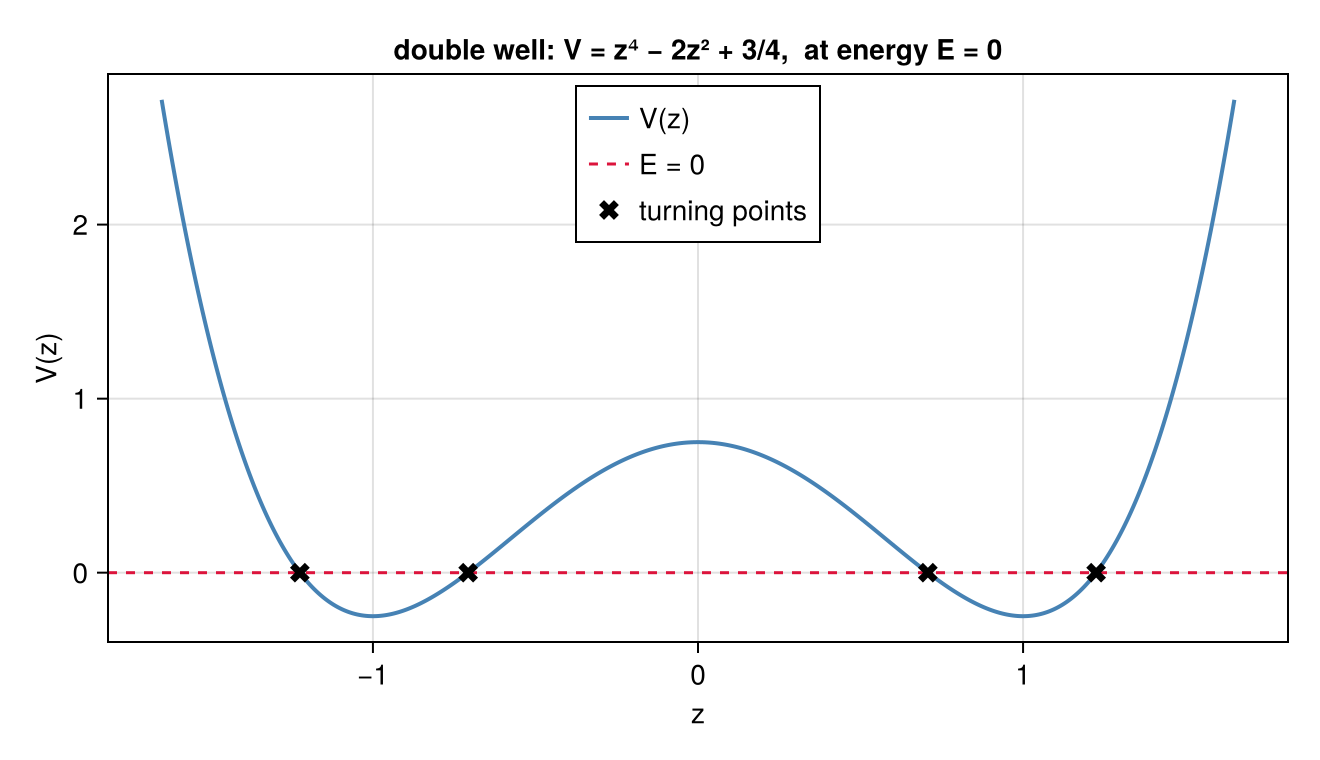

In [10]:
V(z) = z^4 - 2z^2 + 3/4
zs = range(-1.65, 1.65; length = 500)
fig = Figure(size = (660, 380))
ax = Axis(fig[1, 1], xlabel = "z", ylabel = "V(z)",
          title = "double well: V = z⁴ − 2z² + 3/4,  at energy E = 0")
lines!(ax, zs, V.(zs); color = :steelblue, linewidth = 2, label = "V(z)")
hlines!(ax, [0.0]; color = :crimson, linestyle = :dash, label = "E = 0")
scatter!(ax, [Float64(real(location(t))) for t in tps], zeros(4);
         color = :black, marker = :xcross, markersize = 14, label = "turning points")
axislegend(ax; position = :ct)
fig

The four turning points are exactly where the dashed energy line meets the potential, at
$z \approx \pm 0.707$ and $\pm 1.225$. A classical particle at $E = 0$ is trapped in one well or the
other, oscillating between $0.707$ and $1.225$, and the region $|z| < 0.707$ is the forbidden
barrier. Quantum mechanically it tunnels through, and the two would-be degenerate levels split.

The same information in the complex plane.

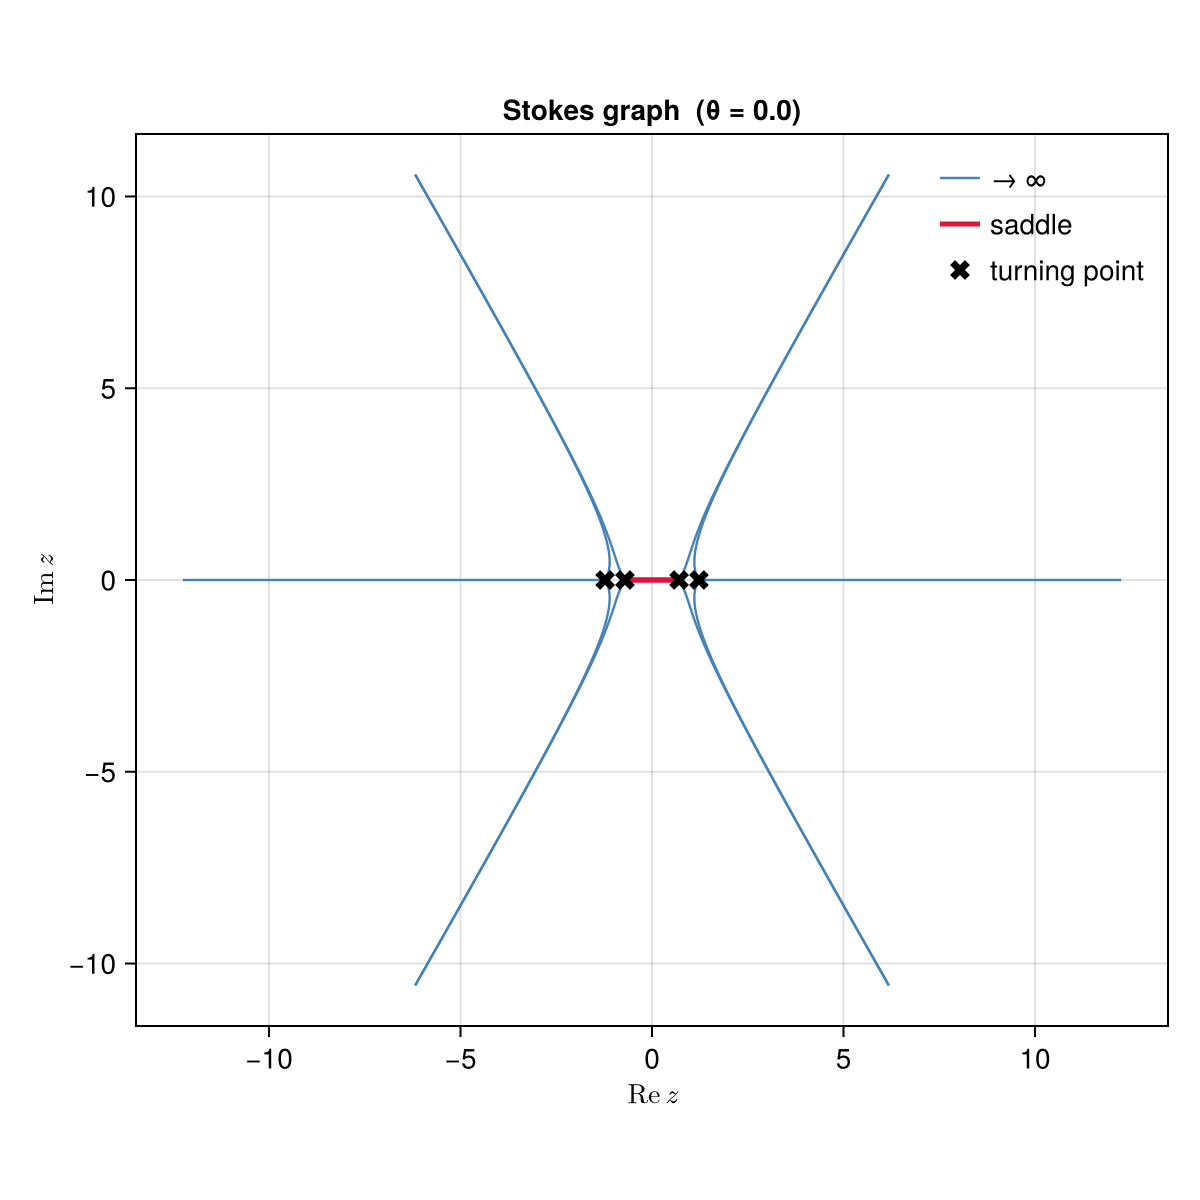

In [11]:
plot_stokes_graph(stokes_graph(prob; theta = 0.0))

### The all-orders expansion

Now go beyond leading order. Substituting $\psi = \exp(\hbar^{-1}\!\int^z\! S)$ into the Schrödinger
equation gives a Riccati equation

$$\hbar\,S' + S^2 = Q,$$

solved recursively with $S = \sum_{m \ge -1} \hbar^m S_m$ starting from $S_{-1} = \sqrt{Q}$. It is
convenient to split $S$ into parts even and odd under swapping the two branches of the square root.
Only the odd part carries physical information, the even part being a total derivative that
integrates to a normalisation.

In [12]:
w = wkb_expansion(prob; order = 8)
println(w)

WKBExpansion(order 8

, exact)


One check before we trust it. The split obeys an exact identity,
$S_{\text{even}} = -\tfrac12\, d\log S_{\text{odd}}/dz$. That is a theorem, so it costs nothing to
run it as a test, and it is a sharp one, since it constrains every order simultaneously.

In [13]:
even_odd_residual(w)   # a theorem, used as an automatic test

5.59308040012263295412285063388956004079246681936559296611058858382342266864946e-74

Zero to seventy-odd digits, the working precision. The recursion is right.

### Quantising a cycle

Integrating $S_{\text{odd}}$ around a closed cycle gives a **Voros symbol**, the exact-WKB
replacement for the Bohr–Sommerfeld action. Its leading term is the classical period
$\oint\sqrt{Q}\,dz$, and everything after it is a series of quantum corrections in $\hbar$.

Take the cycle encircling the two inner turning points $z_2, z_3$, the one that runs around the
barrier.

In [14]:
inner = encircling_contour(tps[2], tps[3])
vs = voros_symbol(w, inner)
println("classical period  = ", r(classical_period(vs)))
Φ = quantum_series(vs)

classical period  = 1.8399

FormalSeries{Complex{BigFloat}}: -1.474500125741145558176502277063808868524758862672953042659413988230184877297856 + 8.636168555094444625386351862800399571116000364436281385023703470168591803162427e-78im*ħ + 19.2110018815496614145326580962125759533210507512594490410551403516562192118024 - 2.210859150104177824098906076876902290205696093295688034566068088363159501609581e-74im*ħ^3 - 1452.779930842174540944578375444156380255171684009250893537828918401361748837082 - 1.60738303649174144523286867413258304107114928766969702865091414296355148405023e-70im*ħ^5 + 269465.0975001953868808598035349860983193425298303140583235426634294089719081946 - 6.811424984034777517277616971982707399654499810655480520244986357251205521028143e-64im*ħ^7 + O(ħ^9)

Look at the coefficients:

$$-1.47,\qquad +19.2,\qquad -1452.8,\qquad +2.7\times10^{5},\qquad\dots$$

Alternating and growing fast. This is problem 2 from the introduction, and the series has zero
radius of convergence.

### Locating the singularity

Factorial growth has structure. If $a_n \sim n!/A^n$, then dividing out the factorial gives
something convergent: the **Borel transform**

$$\hat\Phi(\zeta) = \sum_n \frac{a_n}{n!}\,\zeta^n$$

has a finite radius of convergence and a singularity sitting at $\zeta = A$. Finding that
singularity is finding the action of the missing non-perturbative effect.

To locate it numerically we use a Padé approximant, whose poles accumulate on the singularities of
the function being approximated.

In [15]:
B = Resurgence.borel(Φ)
P = Resurgence.pade(B; reduce = true)   # reduce = true dodges the ħ-parity degeneracy
r(Resurgence.poles(P))

2-element Vector{ComplexF64}:
 -0.0 - 0.40217im
  0.0 + 0.40217im

A conjugate pair on the **imaginary** axis, at $\zeta \approx \pm 0.402\,i$.

That number came from a perturbative series: differentiate a recursion, integrate around a contour,
build a rational approximant, find its poles. No tunnelling was put in anywhere.

Now ask the Stokes graph, which knows nothing about any series, for its catalogue of tunnelling
actions.

In [16]:
foreach(showsaddle, saddles(prob))

  turning points (

1, 2)   |Z| = 0.40287   θ_c = 1.5708
  turning points (2, 3)   |Z| = 1.83992   θ_c = 0.0
  turning points (3, 4)   |Z| = 0.40287   θ_c = 1.5708


The saddle joining $z_1$ and $z_2$ has

$$|Z| = 0.40287 \quad\text{at}\quad \theta_c = \pi/2,$$

matching the Padé pole in modulus *and* in direction: $\theta_c = \pi/2$ says this central charge is
purely imaginary, which is exactly where the poles sit.

**This is the point of the notebook.** The series was expanded around the inner cycle, the one
around the barrier. Its divergence is governed by the action of a *different* object, the saddle
next door, the instanton tunnelling under the neighbouring barrier. Perturbation theory around one
configuration diverges at a rate dictated by another configuration it cannot represent, which
resolves problem 3 from the introduction. The series did know about the tunnelling. It was encoded
in how badly the series failed.

This is checkable rather than rhetorical: the agreement sharpens as we compute more WKB orders.

In [17]:
target = Float64(mass(first(saddles(prob))))
orders = [6, 8, 10, 12, 14, 16]
leading = Float64[]

for ord in orders
    wo = wkb_expansion(prob; order = ord)
    Po = Resurgence.pade(Resurgence.borel(quantum_series(voros_symbol(wo, inner))); reduce = true)
    push!(leading, minimum(abs.(Complex{Float64}.(Resurgence.poles(Po)))))
    println("order ", lpad(ord, 2), ":  |ζ| = ", round(leading[end]; digits = 6),
            "   error = ", round(abs(leading[end] - target); sigdigits = 2))
end

order  6

:  |ζ| = 0.398351   error = 0.0045
order 

 8:  |ζ| = 0.40217   error = 0.0007
order 10

:  |ζ| = 0.403405   error = 0.00054
order 

12:  |ζ| = 0.403234   error = 0.00036
order 14

:  |ζ| = 0.403052   error = 0.00018
order 

16:  |ζ| = 0.402959   error = 8.9e-5


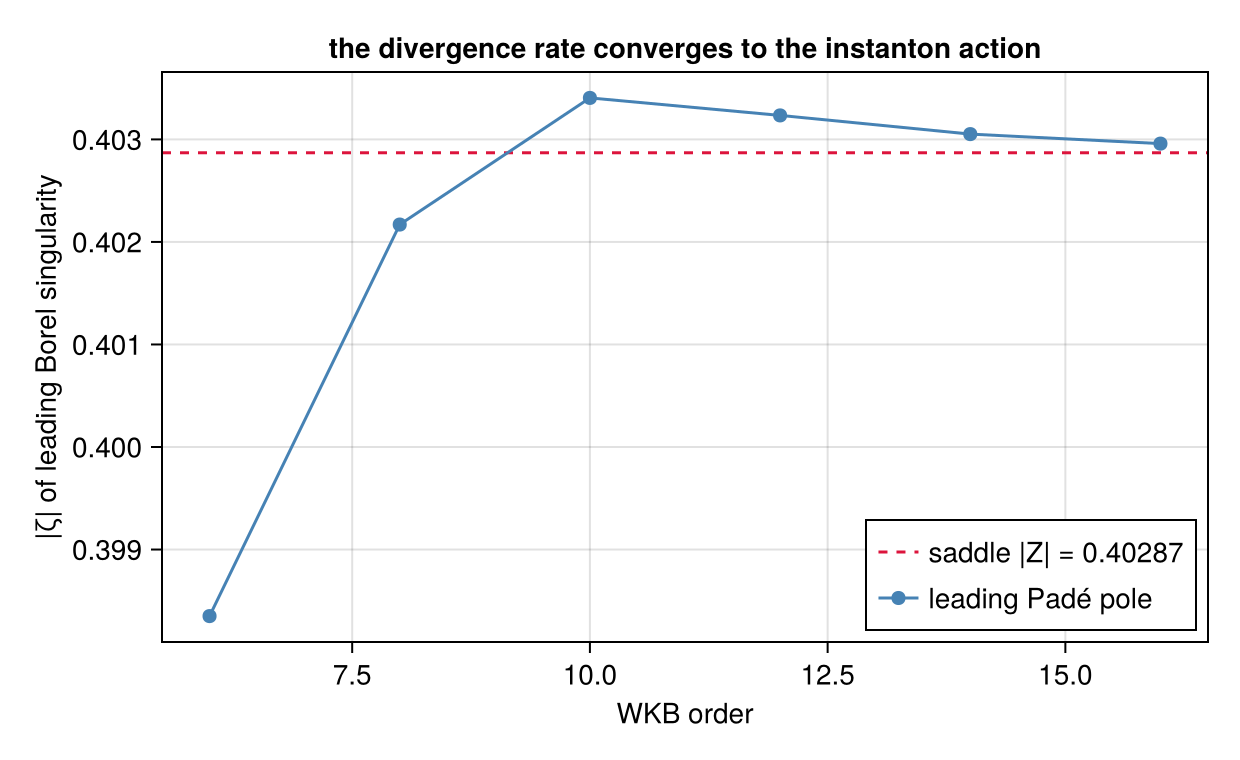

In [18]:
fig = Figure(size = (620, 380))
ax = Axis(fig[1, 1],
          xlabel = "WKB order", ylabel = "|ζ| of leading Borel singularity",
          title = "the divergence rate converges to the instanton action")
hlines!(ax, [target]; color = :crimson, linestyle = :dash,
        label = "saddle |Z| = $(round(target; digits = 5))")
scatterlines!(ax, orders, leading; color = :steelblue, markersize = 10,
              label = "leading Padé pole")
axislegend(ax; position = :rb)
fig

Two computations sharing no code path, one a contour integral of $\sqrt{Q}$ along a finite Stokes
line and the other a pole of a rational approximant to a divergent series, agree to four digits and
improve steadily with order.

*One caveat.* Only the **leading** conjugate pair is reliable here. Padé approximants built from
short series also generate spurious poles, and the extra ones showing up at orders 14–16 are a mix
of genuine higher singularities (at $2A$, $3A$, …) and numerical junk. Separating them takes either
many more orders or a conformal map. `Resurgence.jl` does both, but that is another notebook.

## Where this goes

The dictionary we ended up with:

| analytic side | geometric side |
|---|---|
| WKB breaks down | turning point, $Q(z_*) = 0$ |
| dominant/recessive exchange | Stokes line |
| tunnelling process | saddle connection at phase $\theta_c$ |
| its action $S$ in $e^{-S/\hbar}$ | central charge $Z$ of that connection |
| divergence rate of the series | Borel singularity at $\zeta = Z$ |

Three roads lead out.

**Exact quantisation.** Voros symbols give quantisation conditions that are exact rather than
approximate, and for the double well they reproduce the Zinn-Justin conditions, including the
instanton-induced level splitting we started from. See `quantization_condition`,
`energy_splitting`, `verify_zjj`.

**Wall-crossing.** Rotate $\theta$ through a full turn and saddle connections appear and disappear,
so the catalogue of tunnelling processes changes discontinuously. The jumps follow the
Delabaere–Dillinger–Pham formula, in `ddp.jl`.

**Cluster algebras.** A Stokes graph is dual to a triangulation of a punctured disc. The DDP jump
turns out to be a *mutation* of the associated cluster variables, and the catalogue of saddle
connections over a full turn of $\theta$ is a maximal green sequence. The divergence of a
perturbative series in quantum mechanics is governed by the combinatorics of quiver mutation, which
is where `ClusterAlgebras.jl` meets `ExactWKB.jl`, and the subject of a later notebook.